# 02 · Preprocesamiento — de `data/raw/` a `data/interim/`
**Fase CRISP-DM:** preparación de los datos (1 de 2).

**Objetivo.** Aplicar, en orden, los pasos que fijó el EDA y dejar en `data/interim/` los datasets limpios que
usará el feature engineering: consultas consolidadas, usuarios anómalos, área de estudio, consultas válidas,
cobertura semanal, población Kontur y la tabla por zona con la variable objetivo `query_count`.

**Entradas:** `data/raw/*.csv`, `data/raw/kontur_population_BO_20231101.gpkg.gz`.

**Salidas:**
- `data/interim/`: `queries.parquet`, `usuarios_anomalos.parquet`, `area_estudio.geojson`,
  `queries_limpias.parquet`, `semanas.parquet`, `kontur_2023_h3r8.parquet`, `celdas_objetivo.parquet`.
- `resultados/02_preprocesamiento/`: `flujo_limpieza.csv`, `figuras/` y `metricas.json`.

| § | Paso | Salida en `data/interim/` |
|---|---|---|
| 2 | Consolidar los CSV | `queries.parquet` |
| 3 | Marcar usuarios anómalos | `usuarios_anomalos.parquet` |
| 4 | Delimitar el área de estudio | `area_estudio.geojson` |
| 5 | Filtrar consultas en orden | `queries_limpias.parquet` |
| 6 | Registrar la cobertura semanal | `semanas.parquet` |
| 7 | Extraer la población Kontur | `kontur_2023_h3r8.parquet` |
| 8 | Construir la tabla por zona | `celdas_objetivo.parquet` |
| 9 | Verificar y cerrar | — |

## 1 · Entorno
Borra las salidas de esta fase (resultados e intermedios) para regenerarlas desde `data/raw/`.

In [1]:
# Bootstrap: la raíz es la carpeta con pyproject.toml; se agrega a sys.path para importar config y trufi_ds
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [2]:
from trufi_ds.notebook_setup import *  # noqa: F403  config, pl, pd, np, plt, h3, guardar_*, cronometro
from trufi_ds import eda
from trufi_ds import io as tio
from trufi_ds import preparation as prep
from trufi_ds import preprocesamiento as pre

import json
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

FASE = "02_preprocesamiento"
INTERMEDIOS = [config.QUERIES_CONSOLIDADAS, config.USUARIOS_ANOMALOS, config.AREA_ESTUDIO, config.QUERIES_LIMPIAS,
               config.SEMANAS, config.KONTUR_H3R8, config.CELDAS_OBJETIVO]
limpiar_salidas(FASE, INTERMEDIOS)
config.DATA_INTERIM.mkdir(parents=True, exist_ok=True)
M = {}  # métricas de la fase → metricas.json al cierre
tiempo = cronometro()
AZUL, GRIS, TINTA = "#2a78d6", "#c3c2b7", "#52514e"
# Rampa secuencial que arranca en un azul visible: las zonas con 1 consulta no se confunden con el fondo
SECUENCIAL = LinearSegmentedColormap.from_list("azul", ["#b7d3f6", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])

## 2 · Consolidación
**Tipo de datos:** registros de consultas (texto, numéricos y fecha-hora).

Los 85 CSV se unen en un solo esquema con linaje. El orden es estable (archivo, fecha, usuario, coordenadas):
de él depende qué copia de un duplicado exacto se conserva. **Salida:** `queries.parquet`.

In [3]:
archivos = sorted(config.DATA_RAW.glob("*.csv"))
consultas, registro = tio.leer_consultas(archivos)
consultas = consultas.sort(["source_file", "ts", "userID", "lat_orig", "lon_orig", "lat_dest", "lon_dest"])
assert consultas.height == registro["filas"].sum(), "La consolidación perdió filas"
consultas.write_parquet(config.QUERIES_CONSOLIDADAS)
M.update({"csv_archivos": len(archivos), "consultas_crudas": consultas.height})
tiempo("consolidacion")
print(f"{consultas.height:,} consultas de {len(archivos)} archivos → {config.QUERIES_CONSOLIDADAS.name}")

⏱ consolidacion: 14.6 s (acumulado 15 s)
1,927,675 consultas de 85 archivos → queries.parquet


## 3 · Usuarios anómalos
**Tipo de datos:** comportamiento por usuario (conteos, intervalos y dispersión espacial).

Seis señales por usuario (volumen, intensidad, dispersión, ráfaga, sin rutina, rapidez). Se marca como anómalo
con al menos `MIN_SENALES` señales: una sola (por ejemplo, consultas seguidas) marca a miles de usuarios legítimos.
**Salida:** `usuarios_anomalos.parquet`.

In [4]:
usuarios = pre.senales_por_usuario(consultas)
anomalos = usuarios.filter(pl.col("anomalo")).select("userID", "n_consultas", "n_senales").sort("userID")
anomalos.write_parquet(config.USUARIOS_ANOMALOS)
M.update({"usuarios": usuarios.height, "usuarios_anomalos": anomalos.height,
          "senales_usuario": len([c for c in usuarios.columns if c.startswith("s_")])})
tiempo("usuarios")
anomalos

⏱ usuarios: 14.4 s (acumulado 29 s)


userID,n_consultas,n_senales
str,u32,u32
"""634d8cba-2c48-4672-9fd6-76aa98…",59,2
"""703b4a7a-f753-4538-9ff7-5cb1f9…",174,2


## 4 · Área de estudio
**Tipo de datos:** espaciales (coordenadas de origen y celdas H3).

Envolvente convexa de la componente H3 contigua principal (`K_COMPONENTE`) de los orígenes válidos, más
`BUFFER_AREA_M`. Depende solo de ubicaciones, no de conteos, y no aplica el filtro de distancia: ese filtro decide
qué consultas cuentan, no dónde se mide. **Salida:** `area_estudio.geojson`.

In [5]:
AREA, n_celdas_componente = pre.area_estudio(consultas, anomalos["userID"])
gpd.GeoDataFrame({"regla": [f"componente H3 k={config.K_COMPONENTE} + {config.BUFFER_AREA_M} m"]},
                 geometry=[AREA], crs="EPSG:4326").to_file(config.AREA_ESTUDIO, driver="GeoJSON")
M.update({"area_km2": round(prep.area_km2(AREA), 1), "area_celdas_componente": n_celdas_componente})
tiempo("area")
print({k: M[k] for k in ("area_km2", "area_celdas_componente")})

⏱ area: 7.0 s (acumulado 36 s)
{'area_km2': 1505.7, 'area_celdas_componente': 919}


## 5 · Filtrado de consultas
**Tipo de datos:** registros de consultas.

Se aplican en este orden y se mide cuánto quita cada paso: origen en (0,0) → origen fuera de Bolivia → copias
de duplicados exactos → origen fuera del área → distancia mayor que `DIST_MAX_M` → usuario anómalo.
Cada consulta válida recibe la celda H3 res 8 de su origen. **Salidas:** `queries_limpias.parquet`,
`flujo_limpieza.csv`.

In [6]:
limpias, flujo = prep.clean_queries(consultas, AREA, anomalos["userID"], config.DIST_MAX_M)
limpias = limpias.sort(["source_file", "ts", "userID", "lat_origin", "lon_origin"])
limpias.write_parquet(config.QUERIES_LIMPIAS)
flujo = flujo.with_columns((pl.col("filas_despues") / consultas.height * 100).round(3).alias("pct_conservado"))
M.update({"consultas_validas": limpias.height, "pct_consultas_validas": round(limpias.height / consultas.height * 100, 2)})
M.update({f"eliminadas_{i}": n for i, n in enumerate(flujo["filas_eliminadas"].to_list()[1:], start=1)})
tiempo("filtrado")
guardar_tabla(flujo, "flujo_limpieza", FASE)

⏱ filtrado: 13.3 s (acumulado 49 s)


regla,filas_eliminadas,filas_despues,pct_conservado
str,i64,i64,f64
"""consultas crudas""",0,1927675,100.0
"""origen (0,0)""",3,1927672,100.0
"""origen fuera de Bolivia""",9,1927663,99.999
"""copia de duplicado exacto""",60,1927603,99.996
"""origen fuera del área de estud…",2509,1925094,99.866
"""distancia > 50 km""",283,1924811,99.851
"""usuario anómalo""",233,1924578,99.839


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/02_preprocesamiento/figuras/flujo_limpieza.png')

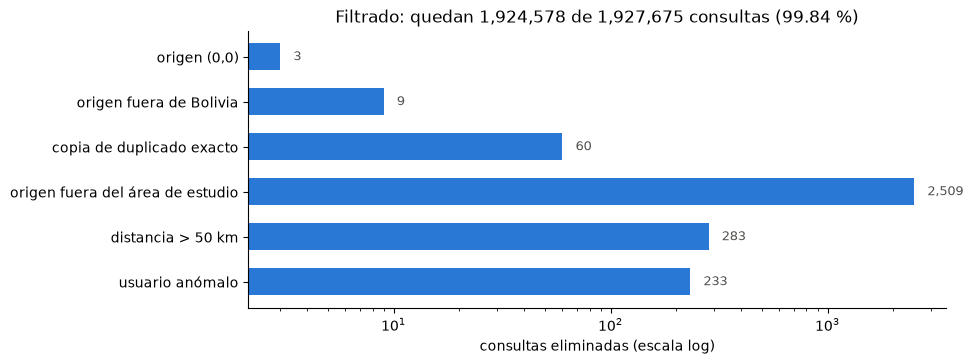

In [7]:
# Filas que quita cada paso (escala log: los pasos difieren en órdenes de magnitud)
pasos = flujo.slice(1)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(pasos["regla"].to_list()[::-1], pasos["filas_eliminadas"].to_list()[::-1], color=AZUL, height=0.6)
for y, v in enumerate(pasos["filas_eliminadas"].to_list()[::-1]):
    ax.text(v * 1.15, y, f"{v:,}", va="center", color=TINTA, fontsize=9)
ax.set(xscale="log", xlabel="consultas eliminadas (escala log)",
       title=f"Filtrado: quedan {limpias.height:,} de {consultas.height:,} consultas ({M['pct_consultas_validas']} %)")
guardar_figura(fig, "flujo_limpieza", FASE)

## 6 · Cobertura semanal
**Tipo de datos:** temporales (semanas ISO y días con datos).

El hueco de semanas sin datos no se imputa. Se registra cada semana (completa, parcial o faltante) y se calcula
`W_obs`, el número de semanas equivalentes observadas (días con datos / 7), para poder normalizar el conteo por
semana. **Salida:** `semanas.parquet`.

In [8]:
semanas = eda.cobertura_semanal(limpias)
semanas.write_parquet(config.SEMANAS)
W_OBS = semanas["dias_con_datos"].sum() / 7
INICIO_HUECO, FIN_HUECO = pre.limites_hueco(semanas)
dias = limpias["ts"].dt.date()
M.update({"semanas_observadas": int(semanas["observada"].sum()), "semanas_completas": int(semanas["completa"].sum()),
          "semanas_faltantes": int((~semanas["observada"]).sum()), "w_obs_semanas": round(W_OBS, 3),
          "hueco_inicio": str(INICIO_HUECO), "hueco_fin": str(FIN_HUECO),
          "dias_antes_hueco": dias.filter(dias < INICIO_HUECO).n_unique(),
          "dias_despues_hueco": dias.filter(dias >= FIN_HUECO).n_unique()})
tiempo("semanas")
print({k: M[k] for k in ("w_obs_semanas", "hueco_inicio", "hueco_fin", "dias_antes_hueco", "dias_despues_hueco")})

⏱ semanas: 4.6 s (acumulado 54 s)
{'w_obs_semanas': 81.143, 'hueco_inicio': '2024-03-11', 'hueco_fin': '2024-04-29', 'dias_antes_hueco': 538, 'dias_despues_hueco': 30}


## 7 · Población Kontur
**Tipo de datos:** espaciales y numéricos (población estimada por celda H3 res 8).

Se extrae la tabla `h3_cell`, `population` de todo Bolivia (sin geometría). Se guarda completa: el feature
engineering suma la población de las coronas vecinas, también fuera del área. **Salida:** `kontur_2023_h3r8.parquet`.

In [9]:
kontur = prep.load_kontur(config.KONTUR_2023_GPKG_GZ).sort("h3_cell")
assert {h3.get_resolution(c) for c in kontur["h3_cell"].head(1000)} == {config.H3_RES}, "Kontur no está en res 8"
kontur.write_parquet(config.KONTUR_H3R8)
M["kontur_celdas"] = kontur.height
tiempo("kontur")
print(f"{kontur.height:,} celdas, {kontur['population'].sum():,} habitantes")

⏱ kontur: 1.1 s (acumulado 55 s)
145,929 celdas, 12,431,735 habitantes


## 8 · Tabla por zona
**Tipo de datos:** numéricos por zona (conteos y población).

Una fila por zona H3 res 8: las zonas Kontur cuyo centroide cae en el área más las zonas con consultas. Las zonas
pobladas sin consultas entran con 0; las zonas con consultas sin registro Kontur quedan con población 0 (ausencia
estructural, no imputación). **Salida:** `celdas_objetivo.parquet`.

| Columna | Descripción |
|---|---|
| `h3_cell` | zona H3 res 8 |
| `query_count` | consultas válidas con origen en la zona (variable objetivo) |
| `user_count` | usuarios distintos con origen en la zona |
| `population` | población Kontur 2023 |
| `query_count_antes_hueco`, `query_count_despues_hueco` | consultas antes y después del hueco temporal |
| `query_rate_week` | `query_count / W_obs`: consultas por semana observada |
| `lat`, `lon` | centroide de la zona |

In [10]:
celdas = prep.build_cell_table(limpias, kontur, AREA)
celdas = (celdas.join(pre.conteos_por_periodo(limpias, INICIO_HUECO, FIN_HUECO), on="h3_cell", how="left")
          .with_columns(pl.col("query_count_antes_hueco", "query_count_despues_hueco").fill_null(0),
                        (pl.col("query_count") / W_OBS).round(4).alias("query_rate_week")))
lat_c, lon_c = prep.cell_centroids(celdas["h3_cell"].to_list())
celdas = celdas.with_columns(pl.Series("lat", lat_c), pl.Series("lon", lon_c)).sort("h3_cell")
celdas.write_parquet(config.CELDAS_OBJETIVO)
q, pob = celdas["query_count"], celdas["population"]
M.update({"celdas_objetivo": celdas.height, "celdas_con_consultas": int((q > 0).sum()),
          "celdas_pobladas_sin_consultas": int(((pob > 0) & (q == 0)).sum()),
          "celdas_poblacion_min": int((pob >= config.POP_MIN).sum()), "poblacion_area": int(pob.sum())})
tiempo("tabla")
celdas.head()

⏱ tabla: 1.6 s (acumulado 57 s)


h3_cell,query_count,user_count,population,query_count_antes_hueco,query_count_despues_hueco,query_rate_week,lat,lon
str,i64,i64,i64,i64,i64,f64,f64,f64
"""888b2c8001fffff""",35,22,253,34,1,0.4313,-17.429585,-66.27015
"""888b2c8003fffff""",3,3,10,3,0,0.037,-17.422968,-66.2754
"""888b2c8005fffff""",0,0,200,0,0,0.0,-17.428167,-66.261581
"""888b2c8007fffff""",4,2,69,4,0,0.0493,-17.421551,-66.26683
"""888b2c8009fffff""",1,1,137,1,0,0.0123,-17.437619,-66.27347


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/02_preprocesamiento/figuras/query_count_mapa.png')

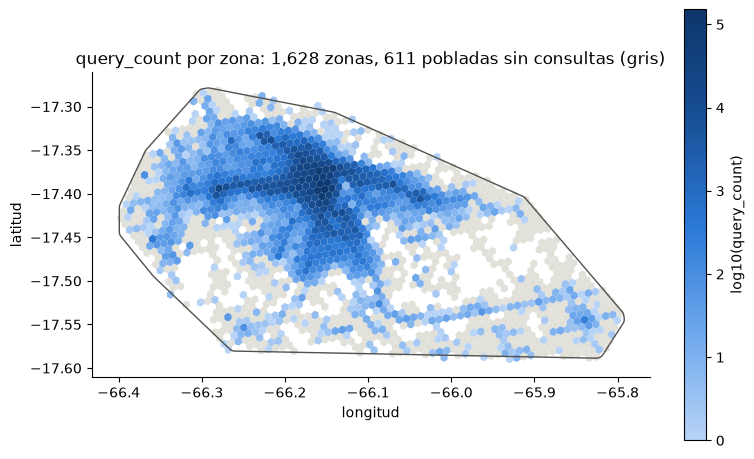

In [11]:
g = gpd.GeoDataFrame(celdas.to_pandas(), geometry=prep.cell_polygons(celdas["h3_cell"].to_list()), crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(9, 8))
g[g["query_count"] == 0].plot(ax=ax, color="#e1e0d9", edgecolor="none")
g[g["query_count"] > 0].assign(log_q=lambda d: np.log10(d["query_count"])).plot(
    ax=ax, column="log_q", cmap=SECUENCIAL, edgecolor="none", legend=True,
    legend_kwds={"label": "log10(query_count)", "shrink": 0.7})
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1)
ax.set(xlabel="longitud", ylabel="latitud",
       title=f"query_count por zona: {M['celdas_objetivo']:,} zonas, {M['celdas_pobladas_sin_consultas']} pobladas sin consultas (gris)")
guardar_figura(fig, "query_count_mapa", FASE)

## 9 · Verificación y cierre
**Tipo de datos:** control (coherencia interna y con el EDA).

El flujo cuadra con el total, el objetivo conserva todas las consultas válidas, no hay nulos ni zonas duplicadas,
y las cifras compartidas coinciden con las que midió el EDA (`resultados/01_eda/metricas.json`).

In [12]:
assert flujo["filas_eliminadas"].sum() + limpias.height == consultas.height
assert celdas["query_count"].sum() == limpias.height, "El objetivo no suma las consultas válidas"
assert (celdas["query_count_antes_hueco"] + celdas["query_count_despues_hueco"] <= celdas["query_count"]).all()
assert celdas["h3_cell"].is_unique().all() and celdas.null_count().sum_horizontal().item() == 0
assert limpias["h3_origin"].null_count() == 0
assert not limpias["userID"].is_in(anomalos["userID"].implode()).any(), "Quedan usuarios anómalos"
# Coherencia con el EDA: mismas reglas, mismas cifras
eda_m = json.loads((config.RESULTADOS / "01_eda" / "metricas.json").read_text())
for clave_pre, clave_eda in [("consultas_validas", "consultas_validas"), ("area_km2", "area_km2"),
                             ("celdas_objetivo", "celdas_region"), ("usuarios_anomalos", "usuarios_anomalos")]:
    assert M[clave_pre] == eda_m[clave_eda], f"{clave_pre}: {M[clave_pre]} ≠ EDA {eda_m[clave_eda]}"
print("Verificaciones superadas")

Verificaciones superadas


In [13]:
M.update({"semilla": config.SEMILLA, "dist_max_m": config.DIST_MAX_M, "buffer_area_m": config.BUFFER_AREA_M,
          "k_componente": config.K_COMPONENTE, "min_senales": config.MIN_SENALES, "pop_min": config.POP_MIN})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.PROJECT_ROOT)}")

⏱ cierre: 2.2 s (acumulado 59 s)
35 métricas → resultados/02_preprocesamiento/metricas.json
